# Kickstarter Campaign Data Collection

This notebook constructs the raw dataset used in the project. It combines campaign metadata from the Web Robots Kickstarter dataset with long-form campaign descriptions collected from the corresponding Kickstarter pages.

The main steps are:

1. Load and combine the raw campaign metadata files.
2. Select eligible campaigns and the five categories included in the analysis.
3. Extract the corresponding Kickstarter project URLs.
4. Collect long-form campaign descriptions through web scraping.
5. Merge the scraped descriptions with the original campaign metadata.

In [1]:
import ast
import json
import random
import time
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
from bs4 import BeautifulSoup
from selenium import webdriver
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.common.by import By
from selenium.webdriver.support import expected_conditions as EC
from selenium.webdriver.support.ui import WebDriverWait
from webdriver_manager.chrome import ChromeDriverManager

## 0. Scraping progress files

During data collection:

- `scraped_campaigns.csv` stores campaigns whose descriptions were successfully retrieved and satisfied the minimum-length requirement.
- `scraped_urls.txt` records the URLs already processed, preventing the same campaigns from being selected in subsequent batches.
- `raw_kickstarter.csv` contains the final dataset obtained by merging scraped descriptions with campaign metadata.
- URLs that produce temporary scraping errors are not marked as processed, allowing them to be retried later.

## 1. Loading the Kickstarter metadata

Campaign metadata were obtained from the [Web Robots Kickstarter dataset](https://webrobots.io/kickstarter-datasets/). The selected snapshot is distributed across 85 CSV files, which are combined into a single DataFrame.

The source files contain campaign-level information, including funding goals, pledged amounts, categories, launch and deadline dates, and links to the corresponding Kickstarter pages. These links are subsequently used to collect the full campaign descriptions.

In [2]:
DATASET_DIR = Path("Kickstarter_2026-03-12T03_20_26_556Z")
csv_files = sorted(DATASET_DIR.glob("*.csv"))

if not csv_files:
    raise FileNotFoundError(
        f"No CSV files found in {DATASET_DIR.resolve()}. "
        "Download and extract the dataset before running this notebook."
    )

df = pd.concat(
    (pd.read_csv(file) for file in csv_files),
    ignore_index=True
)

print(f"Files loaded: {len(csv_files)}")
print(f"Combined dataset shape: {df.shape}")

Files loaded: 85
Combined dataset shape: (268539, 42)


## 2. Initial sample selection

The empirical distribution of campaign funding goals is inspected before defining the analytical sample. To focus the analysis on relatively substantial fundraising projects, campaigns with a funding goal below USD 5,000 are excluded (this threshold is a modelling and sampling choice but it does not imply that campaigns with lower funding goals are invalid or inauthentic).

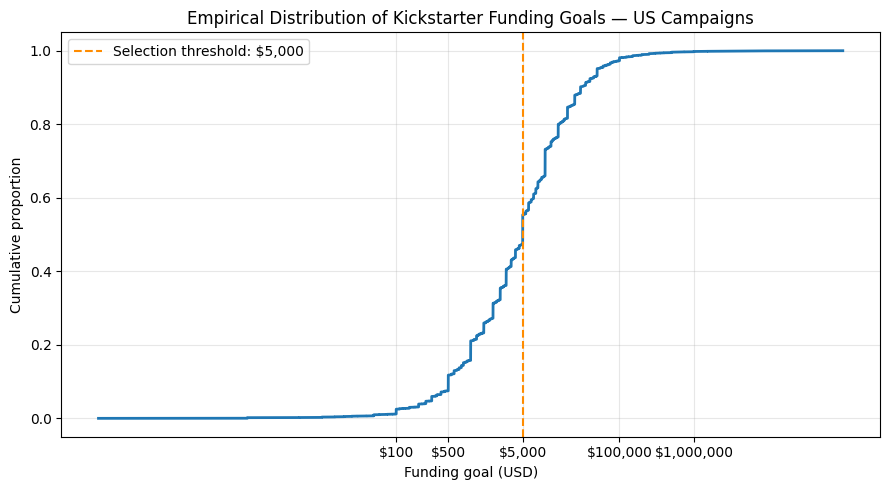

In [3]:
# Select valid funding goals for US campaigns
us_goals = (
    df.loc[
        df["country"].eq("US") & df["goal"].gt(0),
        "goal"
    ]
    .dropna()
    .sort_values()
    .to_numpy()
)

# Compute the empirical cumulative distribution function
cumulative_proportion = (
    np.arange(1, len(us_goals) + 1) / len(us_goals)
)

fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(
    us_goals,
    cumulative_proportion,
    linewidth=2
)

ax.axvline(
    5_000,
    color="darkorange",
    linestyle="--",
    linewidth=1.5,
    label="Selection threshold: $5,000"
)

ax.set_xscale("log")

ticks = [100, 500, 5_000, 100_000, 1_000_000]
ticks = [
    value for value in ticks
    if us_goals.min() <= value <= us_goals.max()
]

ax.set_xticks(ticks)
ax.set_xticklabels([f"${value:,.0f}" for value in ticks])
ax.xaxis.set_minor_formatter(mticker.NullFormatter())

ax.set_xlabel("Funding goal (USD)")
ax.set_ylabel("Cumulative proportion")
ax.set_title("Empirical Distribution of Kickstarter Funding Goals — US Campaigns")

ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

The vertical line indicates the USD 5,000 threshold used to define the analytical sample. Campaigns below this value are excluded from the subsequent data collection and analysis.

## 3. Category Selection

Kickstarter campaigns are organised into specific subcategories and broader parent categories. For example, *Hardware* is a subcategory of *Technology*. Since this information is stored as a JSON string in the raw dataset, it is parsed to extract both category levels.

The analysis focuses on the five most represented parent categories, ensuring sufficiently large samples for category-specific exploratory and predictive analyses.

In [4]:
def parse_category(value):
    """Convert a category JSON string into a Python dictionary."""
    if pd.isna(value):
        return {}

    try:
        return json.loads(value)
    except (json.JSONDecodeError, TypeError):
        try:
            return ast.literal_eval(value)
        except (ValueError, SyntaxError):
            return {}

# Parse category information
category_data = df["category"].apply(parse_category)

# Extract subcategories and broader parent categories
df["subcategory"] = category_data.apply(
    lambda item: item.get("name")
)

df["parent_category"] = category_data.apply(
    lambda item: item.get("parent_name") or item.get("name")
)

# Count campaigns by parent category
category_counts = (
    df["parent_category"]
    .value_counts()
    .rename_axis("category")
    .reset_index(name="campaigns")
)

# Select the five most represented parent categories
SELECTED_CATEGORIES = (
    category_counts
    .head(5)["category"]
    .tolist()
)

display(category_counts)
print("Selected categories:", SELECTED_CATEGORIES)

,category,campaigns
0,Film & Video,34913
1,Music,30441
2,Publishing,29346
3,Games,24826
4,Technology,24323
5,Art,21177
6,Food,19818
7,Fashion,14873
8,Design,13846
9,Comics,13183


Selected categories: ['Film & Video', 'Music', 'Publishing', 'Games', 'Technology']


## 4. Eligibility Filters

Before collecting the full campaign descriptions, the metadata are filtered to define the pool of eligible campaigns. The sample is restricted to campaigns that:

- were launched in the United States;
- had a funding goal of at least USD 5,000;
- received a positive pledged amount and reached more than 1% of their funding goal;
- were not cancelled;
- belonged to one of the five selected parent categories;
- reported consistent values for `usd_pledged` and `converted_pledged_amount`.

These criteria reproduce the sampling procedure used to construct the dataset analysed in the subsequent notebooks. They should be regarded as sample-selection choices, as they exclude smaller campaigns and projects with extremely limited funding.

In [5]:
# Restrict the sample to US campaigns with positive funding
eligible_campaigns = df.loc[
    df["country"].eq("US")
    & df["usd_pledged"].gt(0)
    & df["goal"].ge(5_000)
    & df["state"].ne("canceled")
    & df["parent_category"].isin(SELECTED_CATEGORIES)
    & df["usd_pledged"].eq(df["converted_pledged_amount"])
].copy()

# Calculate the percentage of the funding goal reached
eligible_campaigns["pct_goal_reached"] = (
    eligible_campaigns["usd_pledged"]
    / eligible_campaigns["goal"]
    * 100
)

# Exclude campaigns that reached no more than 1% of their goal
eligible_campaigns = eligible_campaigns.loc[
    eligible_campaigns["pct_goal_reached"].gt(1)
].copy()

print(f"Eligible campaigns: {len(eligible_campaigns):,}")

display(
    eligible_campaigns["parent_category"]
    .value_counts()
    .rename_axis("category")
    .reset_index(name="campaigns")
)

Eligible campaigns: 30,575


,category,campaigns
0,Film & Video,8661
1,Music,8379
2,Technology,5298
3,Publishing,5142
4,Games,3095


The source dataset includes only a short campaign blurb rather than the complete long-form text required for the NLP analysis. The full campaign descriptions are therefore collected from the corresponding Kickstarter project pages.

## 5. Project URL Extraction and Progress Tracking

The raw metadata store the links associated with each campaign as JSON strings. The official Kickstarter project URL is extracted from each record and used to access the corresponding campaign page.

Campaigns with missing or duplicated URLs are removed before scraping. A separate text file records previously processed URLs, allowing data collection to be resumed across multiple sessions without repeatedly selecting the same campaigns. URLs associated with temporary scraping errors remain eligible for subsequent attempts.

In [6]:
def extract_project_url(value):
    """Extract the official Kickstarter project URL from a JSON string."""
    if pd.isna(value):
        return None

    try:
        parsed = json.loads(value)
    except (json.JSONDecodeError, TypeError):
        try:
            parsed = ast.literal_eval(value)
        except (ValueError, SyntaxError):
            return None

    return parsed.get("web", {}).get("project")


# Extract and standardise project URLs
eligible_campaigns["project_url"] = (
    eligible_campaigns["urls"]
    .apply(extract_project_url)
    .str.rstrip("/")
)

# Remove campaigns with missing or duplicated URLs
valid_campaigns = (
    eligible_campaigns
    .dropna(subset=["project_url"])
    .drop_duplicates(subset=["project_url"])
    .copy()
)

print(f"Eligible campaigns: {len(eligible_campaigns):,}")
print(f"Campaigns with valid unique URLs: {len(valid_campaigns):,}")

display(
    valid_campaigns[
        ["name", "parent_category", "project_url"]
    ].head()
)

Eligible campaigns: 30,575
Campaigns with valid unique URLs: 24,842


,name,parent_category,project_url
3,Giada AI PC - AI Power. PC Performance. Redefi...,Technology,https://www.kickstarter.com/projects/giada-ai-...
27,AE-WWII: European Theater,Games,https://www.kickstarter.com/projects/blackball...
36,Election War Room 2012 - iPhone Board Game abo...,Games,https://www.kickstarter.com/projects/claw/elec...
42,Black Raspberry desktop computer case,Technology,https://www.kickstarter.com/projects/boltind/b...
56,Chupi Goes Cow-Tipping,Games,https://www.kickstarter.com/projects/181882321...


In [7]:
# Identify the repository root regardless of where the notebook is launched
current_directory = Path.cwd()

if current_directory.name.lower() in {"notebook", "notebooks"}:
    project_root = current_directory.parent
else:
    project_root = current_directory

data_directory = project_root / "data"
data_directory.mkdir(exist_ok=True)

tracking_file = data_directory / "scraped_urls.txt"

# Load URLs processed during previous scraping sessions
if tracking_file.exists():
    processed_urls = {
        url.strip().rstrip("/")
        for url in tracking_file.read_text(encoding="utf-8").splitlines()
        if url.strip()
    }
else:
    processed_urls = set()

# Retain only campaigns that have not been processed
remaining_campaigns = valid_campaigns.loc[
    ~valid_campaigns["project_url"].isin(processed_urls)
].copy()

print(f"Previously processed URLs: {len(processed_urls):,}")
print(f"Campaigns remaining: {len(remaining_campaigns):,}")

display(
    remaining_campaigns["parent_category"]
    .value_counts()
    .rename_axis("category")
    .reset_index(name="remaining_campaigns")
)

Previously processed URLs: 0
Campaigns remaining: 24,842


,category,remaining_campaigns
0,Film & Video,7030
1,Music,6863
2,Publishing,4341
3,Technology,4325
4,Games,2283


## 6. Balanced Batch Sampling

Campaign descriptions are collected in balanced batches to prevent the largest Kickstarter categories from dominating the final dataset. At each iteration, the same number of previously unprocessed campaigns is sampled from each of the five selected categories.

A fixed random seed makes the selected batch reproducible, provided that the underlying pool of remaining campaigns is unchanged.

In [8]:
N_PER_CATEGORY = 100
RANDOM_STATE = 42

available_campaigns = (
    remaining_campaigns["parent_category"]
    .value_counts()
)

# Verify that every category contains enough campaigns
insufficient_categories = available_campaigns[
    available_campaigns < N_PER_CATEGORY
]

if not insufficient_categories.empty:
    raise ValueError(
        "The following categories do not contain enough remaining "
        f"campaigns for a sample of {N_PER_CATEGORY}:\n"
        f"{insufficient_categories}"
    )

# Draw the same number of campaigns from each category
sampled_campaigns = (
    remaining_campaigns
    .groupby("parent_category", group_keys=False)
    .sample(
        n=N_PER_CATEGORY,
        random_state=RANDOM_STATE
    )
    .reset_index(drop=True)
)

batch_urls = sampled_campaigns["project_url"].tolist()

print(f"Campaigns sampled per category: {N_PER_CATEGORY}")
print(f"Total campaigns in the batch: {len(sampled_campaigns):,}")

display(
    sampled_campaigns["parent_category"]
    .value_counts()
    .rename_axis("category")
    .reset_index(name="sampled_campaigns")
)

Campaigns sampled per category: 100
Total campaigns in the batch: 500


,category,sampled_campaigns
0,Film & Video,100
1,Games,100
2,Music,100
3,Publishing,100
4,Technology,100


## 7. Campaign Description Scraping

The complete campaign descriptions are collected from the corresponding Kickstarter project pages using Selenium and Beautiful Soup.

A single headless Chrome session is reused across the entire batch to reduce execution time and avoid repeatedly initialising the browser. Selenium loads the dynamically rendered page, while Beautiful Soup extracts the campaign title and long-form description from the resulting HTML.

Funding and category information are not extracted again from the webpage because they are already available in the original campaign metadata.

In [9]:
def create_webdriver():
    """Create and configure a headless Chrome WebDriver."""
    options = webdriver.ChromeOptions()

    options.add_argument("--headless=new")
    options.add_argument("--no-sandbox")
    options.add_argument("--disable-dev-shm-usage")
    options.add_argument("--disable-gpu")
    options.add_argument("--disable-extensions")
    options.add_argument("--window-size=1920,1080")

    driver = webdriver.Chrome(
        service=Service(ChromeDriverManager().install()),
        options=options
    )

    driver.set_page_load_timeout(30)

    return driver

In [10]:
def scrape_campaign_page(driver, url):
    """
    Extract the title and long-form description from a Kickstarter page.

    Parameters
    ----------
    driver : selenium.webdriver.Chrome
        Active Chrome WebDriver instance.
    url : str
        URL of the Kickstarter campaign.

    Returns
    -------
    dict
        Campaign URL, title, and complete description.
    """
    driver.get(url)

    WebDriverWait(driver, 15).until(
        EC.presence_of_element_located(
            (By.CSS_SELECTOR, ".rte__content")
        )
    )

    soup = BeautifulSoup(driver.page_source, "html.parser")

    description_element = soup.select_one(".rte__content")
    description = (
        description_element.get_text(separator=" ", strip=True)
        if description_element is not None
        else None
    )

    title_element = (
        soup.select_one("h1.project-name")
        or soup.select_one("h1")
        or soup.select_one("h2")
    )

    title = (
        title_element.get_text(separator=" ", strip=True)
        if title_element is not None
        else None
    )

    return {
        "project_url": url,
        "scraped_title": title,
        "description": description,
    }

## 8. Batch Execution and Progressive Saving

Only campaign descriptions containing at least 800 characters are retained, ensuring that the subsequent NLP analyses are based on sufficiently informative long-form text. This threshold is a sample-selection choice and may favour campaigns with more detailed project pages.

The selected URLs are processed using a single browser session. Results and processed URLs are saved every ten requests so that data collection can be resumed if the execution is interrupted. URLs associated with temporary errors are not marked as processed and may therefore be retried in a subsequent batch.

In [ ]:
MIN_DESCRIPTION_LENGTH = 800
SAVE_EVERY = 10

scraped_data_file = data_directory / "scraped_campaigns.csv"

new_rows = []
successful_scrapes = 0
short_or_missing = 0
temporary_errors = 0

def save_progress(rows, processed_urls):
    """Append new campaigns and save the set of processed URLs."""
    if rows:
        pd.DataFrame(rows).to_csv(
            scraped_data_file,
            mode="a",
            header=not scraped_data_file.exists(),
            index=False
        )
        rows.clear()

    tracking_file.write_text(
        "\n".join(sorted(processed_urls)),
        encoding="utf-8"
    )

driver = create_webdriver()

try:
    for index, url in enumerate(batch_urls, start=1):
        print(f"[{index}/{len(batch_urls)}] Processing campaign")

        try:
            scraped_campaign = scrape_campaign_page(driver, url)

            description = scraped_campaign.get("description")

            # The page was processed successfully, even if its text is excluded
            processed_urls.add(url)

            if (
                description is not None
                and len(description) >= MIN_DESCRIPTION_LENGTH
            ):
                new_rows.append(scraped_campaign)
                successful_scrapes += 1
                print(
                    f"  Saved: {len(description):,} characters"
                )
            else:
                short_or_missing += 1
                print("  Excluded: description missing or too short")

        except Exception as error:
            temporary_errors += 1
            print(f"  Temporary error: {type(error).__name__}")

        finally:
            # Pause between requests to avoid sending them too rapidly
            time.sleep(random.uniform(4, 9))

        if index % SAVE_EVERY == 0:
            save_progress(new_rows, processed_urls)
            print(f"  Progress saved after {index} requests")

finally:
    # Save any remaining results before closing the browser
    save_progress(new_rows, processed_urls)
    driver.quit()

print("\nBatch completed")
print(f"Descriptions saved: {successful_scrapes:,}")
print(f"Descriptions excluded: {short_or_missing:,}")
print(f"Temporary errors: {temporary_errors:,}")
print(f"Total processed URLs: {len(processed_urls):,}")

## 9. Final Dataset Construction

The successfully scraped campaign descriptions are merged with the corresponding metadata using the project URL as a unique identifier. The resulting dataset contains the textual content required for the NLP analysis together with campaign category, funding information, launch and deadline dates, and video availability.

Duplicate campaigns and observations without a valid description are removed before the final raw dataset is saved for the data-preparation stage.

In [ ]:
if not scraped_data_file.exists():
    raise FileNotFoundError(
        f"No scraped campaign data found at {scraped_data_file}. "
        "Run the scraping section before constructing the final dataset."
    )

# Load all descriptions collected across scraping sessions
scraped_campaigns = pd.read_csv(scraped_data_file)

required_scraped_columns = [
    "project_url",
    "scraped_title",
    "description",
]

missing_columns = set(required_scraped_columns) - set(
    scraped_campaigns.columns
)

if missing_columns:
    raise ValueError(
        "The scraped dataset is missing the following columns: "
        f"{sorted(missing_columns)}"
    )

scraped_campaigns = scraped_campaigns[
    required_scraped_columns
].copy()

scraped_campaigns["project_url"] = (
    scraped_campaigns["project_url"]
    .str.rstrip("/")
)

scraped_campaigns = (
    scraped_campaigns
    .dropna(subset=["project_url", "description"])
    .drop_duplicates(subset=["project_url"], keep="last")
    .copy()
)

# Select the metadata required by the subsequent analyses
metadata_columns = [
    "project_url",
    "parent_category",
    "goal",
    "pledged",
    "usd_pledged",
    "converted_pledged_amount",
    "currency",
    "launched_at",
    "deadline",
    "video",
]

campaign_metadata = (
    valid_campaigns[metadata_columns]
    .drop_duplicates(subset=["project_url"])
    .copy()
)

campaign_metadata = campaign_metadata.rename(
    columns={"parent_category": "category"}
)

# Merge scraped text with the original campaign metadata
campaigns = scraped_campaigns.merge(
    campaign_metadata,
    on="project_url",
    how="left",
    validate="one_to_one"
)

# Use the column name expected by the next notebook
campaigns = campaigns.rename(
    columns={"project_url": "url"}
)

# Remove observations that could not be matched
campaigns = campaigns.dropna(
    subset=["category", "goal", "launched_at", "deadline"]
).reset_index(drop=True)

final_raw_data_file = data_directory / "raw_kickstarter.csv"
campaigns.to_csv(final_raw_data_file, index=False)

print(f"Scraped descriptions loaded: {len(scraped_campaigns):,}")
print(f"Successfully matched campaigns: {len(campaigns):,}")
print(f"Final dataset saved to: {final_raw_data_file}")

display(
    campaigns["category"]
    .value_counts()
    .rename_axis("category")
    .reset_index(name="campaigns")
)

The resulting file, `data/raw_kickstarter.csv`, is the input to `02_data_preparation.ipynb`. The next stage derives the campaign outcome, duration, and cleaned textual representations used throughout the project.